Original shape: (891, 8)
Reduced shape after PCA: (891, 7)


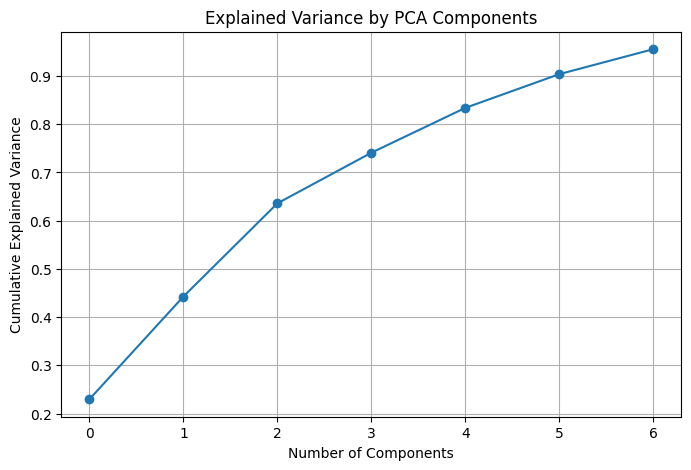

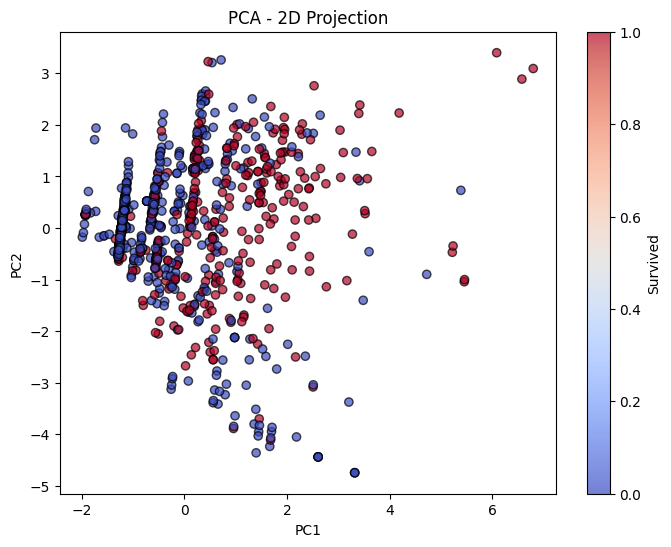

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load cleaned, encoded dataset (same as from Day 27)
df = pd.read_csv('../day01-python-warmups/train.csv')

# Drop irrelevant columns
df = df.drop(['Ticket', 'Cabin', 'Name', 'PassengerId'], axis=1)

# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encode categorical features
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

df_encoded.head()

X = df_encoded.drop('Survived', axis=1)

# Standardize features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize PCA to capture 95% variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X.shape}")
print(f"Reduced shape after PCA: {X_pca.shape}")


plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

# Reduce to 2 components for visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df_encoded['Survived'], cmap='coolwarm', edgecolor='k', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - 2D Projection')
plt.colorbar(label='Survived')
plt.show()
